<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Wrangling Lab**


Estimated time needed: **45** minutes


In this lab, you will perform data wrangling tasks to prepare raw data for analysis. Data wrangling involves cleaning, transforming, and organizing data into a structured format suitable for analysis. This lab focuses on tasks like identifying inconsistencies, encoding categorical variables, and feature transformation.


## Objectives


After completing this lab, you will be able to:


- Identify and remove inconsistent data entries.

- Encode categorical variables for analysis.

- Handle missing values using multiple imputation strategies.

- Apply feature scaling and transformation techniques.


#### Install the required libraries


In [1]:
# !pip install pandas
# !pip install matplotlib

## Tasks


#### Step 1: Import the necessary module.


### 1. Load the Dataset


<h5>1.1 Import necessary libraries and load the dataset.</h5>


Ensure the dataset is loaded correctly by displaying the first few rows.


In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the Stack Overflow survey data
dataset_url = "survey_sample.csv"
df = pd.read_csv(dataset_url)

# Display the first few rows
df.head()

,index,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,36662,36663,I am a developer by profession,18-24 years old,I prefer not to say,NaN,Apples,NaN,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;On the job training;Sch...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Neither easy nor difficult,NaN,NaN
1,36720,36721,I am a developer by profession,25-34 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;Contribute to open-source projects,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",On the job training;Other online resources (e....,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,84851.0,NaN
2,30718,30719,"I am not primarily a developer, but I write co...",25-34 years old,"Employed, full-time",Remote,Apples,Hobby;Professional development or self-paced l...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",On the job training;Other online resources (e....,...,17.0,18.0,20.0,10.0,5.0,2.0,Appropriate in length,Easy,80000.0,7.0
3,17353,17354,I am a developer by profession,35-44 years old,"Independent contractor, freelancer, or self-em...",Remote,Apples,Bootstrapping a business,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Other online resources ...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,75184.0,NaN
4,39838,39839,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","School (i.e., University, College, etc);Friend...",...,20.0,25.0,20.0,25.0,0.0,0.0,Appropriate in length,Easy,332712.0,9.0


#### 2. Explore the Dataset


<h5>2.1 Summarize the dataset by displaying the column data types, counts, and missing values.</h5>


In [3]:
# Display data types and non-null counts for each column
print("=== Dataset Info ===")
print(df.info())

# Display the number of missing values per column (top 20)
print("\n=== Missing Values (Top 20 columns) ===")
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0].head(20))

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Columns: 115 entries, index to JobSat
dtypes: float64(13), int64(2), object(100)
memory usage: 898.6+ KB
None

=== Missing Values (Top 20 columns) ===
                               Missing Count  Missing %
AINextMuch less integrated               987       98.7
AINextLess integrated                    960       96.0
AINextNo change                          826       82.6
AINextMuch more integrated               788       78.8
EmbeddedAdmired                          754       75.4
EmbeddedWantToWorkWith                   739       73.9
EmbeddedHaveWorkedWith                   655       65.5
AIToolNot interested in Using            640       64.0
ConvertedCompYearly                      634       63.4
AINextMore integrated                    634       63.4
Knowledge_7                              581       58.1
Knowledge_8                              580       58.0
Knowledge_9                

<h5>2.2 Generate basic statistics for numerical columns.</h5>


In [4]:
# Generate descriptive statistics for all numerical columns
print("=== Basic Statistics for Numerical Columns ===")
print(df.describe())

=== Basic Statistics for Numerical Columns ===
             index   ResponseId     CompTotal     WorkExp  JobSatPoints_1  \
count   1000.00000   1000.00000  5.390000e+02  456.000000      453.000000   
mean   32765.61000  32766.61000  2.569828e+07   11.539474       18.247241   
std    19434.50674  19434.50674  4.333613e+08    9.320813       25.262354   
min      114.00000    115.00000  0.000000e+00    0.000000        0.000000   
25%    15398.50000  15399.50000  5.500000e+04    5.000000        0.000000   
50%    32679.50000  32680.50000  1.056000e+05    9.000000       10.000000   
75%    50479.75000  50480.75000  2.135000e+05   16.000000       20.000000   
max    65351.00000  65352.00000  9.600000e+09   48.000000      100.000000   

       JobSatPoints_4  JobSatPoints_5  JobSatPoints_6  JobSatPoints_7  \
count      455.000000      455.000000      455.000000      454.000000   
mean         6.760440        9.554945       25.417582       23.048458   
std         16.914067       20.808553   

### 3. Identifying and Removing Inconsistencies


<h5>3.1 Identify inconsistent or irrelevant entries in specific columns (e.g., Country).</h5>


In [5]:
# View all unique values in the Country column
print("=== Unique Countries ===")
print(df['Country'].unique())
print(f"\nTotal unique countries: {df['Country'].nunique()}")

# Check for missing values in Country
print(f"Missing Country values: {df['Country'].isnull().sum()}")

# View distribution of top 15 countries
print("\n=== Top 15 Countries ===")
print(df['Country'].value_counts().head(15))

=== Unique Countries ===
['Viet Nam' 'Germany' 'United States of America' 'India' 'France'
 'Ukraine' nan 'United Kingdom of Great Britain and Northern Ireland'
 'Spain' 'Czech Republic' 'Austria' 'Denmark' 'Italy' 'Colombia' 'Poland'
 'Guatemala' 'Australia' 'Canada' 'Bulgaria'
 'Iran, Islamic Republic of...' 'Ecuador' 'United Arab Emirates' 'Belgium'
 'China' 'Norway' 'Nepal' 'Sweden' 'Benin' 'Portugal' 'Bangladesh'
 'Turkey' 'Japan' 'Slovenia' 'Zimbabwe' 'Tunisia' 'Qatar' 'Netherlands'
 'Taiwan' 'Cameroon' 'Georgia' 'Finland' 'Romania' 'Ghana' 'Saudi Arabia'
 'Brazil' 'Switzerland' 'Hungary' 'Dominican Republic' 'Israel' 'Egypt'
 'South Africa' 'Kenya' 'Greece' 'Nigeria' 'Ireland' 'Lithuania' 'Bolivia'
 'Thailand' 'Malaysia' 'Pakistan' 'Uruguay' 'Russian Federation'
 'Hong Kong (S.A.R.)' 'Afghanistan' 'Mexico' 'Indonesia' 'Croatia'
 'Bosnia and Herzegovina' 'Slovakia' 'Kazakhstan' 'Serbia' 'New Zealand'
 'Singapore' 'San Marino' 'South Korea' 'Philippines' 'Latvia'
 'Uzbekistan' 'Co

<h5>3.2 Standardize entries in columns like Country or EdLevel by mapping inconsistent values to a consistent format.</h5>


In [6]:
# --- Standardize Country column ---
# Map verbose country names to shorter, consistent labels
country_mapping = {
    'United Kingdom of Great Britain and Northern Ireland': 'United Kingdom',
    'United States of America': 'United States',
    'Iran, Islamic Republic of...': 'Iran',
    'Russian Federation': 'Russia',
    'Viet Nam': 'Vietnam',
    'Bolivia, Plurinational State of...': 'Bolivia',
    'Venezuela, Bolivarian Republic of...': 'Venezuela',
    'Hong Kong (S.A.R.)': 'Hong Kong',
    'Taiwan, Province of China...': 'Taiwan',
    "Korea, Republic of": 'South Korea',
    "Democratic People's Republic of Korea": 'North Korea',
    'Republic of Moldova': 'Moldova',
    'Syrian Arab Republic': 'Syria',
    'Czech Republic': 'Czech Republic'
}
df['Country'] = df['Country'].replace(country_mapping)
print("Country column standardized.")
print(df['Country'].value_counts().head(10))

# --- Standardize EdLevel column ---
# Shorten long education level strings to concise labels
edlevel_mapping = {
    'Bachelor\u2019s degree (B.A., B.S., B.Eng., etc.)': 'Bachelor\'s',
    'Master\u2019s degree (M.A., M.S., M.Eng., MBA, etc.)': 'Master\'s',
    'Professional degree (JD, MD, Ph.D, Ed.D, etc.)': 'Professional/PhD',
    'Associate degree (A.A., A.S., etc.)': 'Associate',
    'Some college/university study without earning a degree': 'Some College',
    'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)': 'High School',
    'Primary/elementary school': 'Primary School',
    'Something else': 'Other'
}
df['EdLevel'] = df['EdLevel'].replace(edlevel_mapping)
print("\nEdLevel column standardized.")
print(df['EdLevel'].value_counts())

Country column standardized.
Country
United States     171
Germany            84
India              64
United Kingdom     49
Ukraine            41
Canada             31
Italy              26
Poland             24
Spain              24
Australia          23
Name: count, dtype: int64

EdLevel column standardized.
EdLevel
Bachelor's          374
Master's            247
Some College        126
High School          83
Professional/PhD     44
Associate            29
Primary School       22
Other                12
Name: count, dtype: int64


### 4. Encoding Categorical Variables


<h5>4.1 Encode the Employment column using one-hot encoding.</h5>


In [7]:
# The Employment column can contain multiple values separated by semicolons.
# We split each entry and apply one-hot encoding across all unique categories.

# Step 1: Split multi-value entries and explode into individual categories
employment_dummies = df['Employment'].str.get_dummies(sep=';')

# Step 2: Add a prefix for clarity
employment_dummies.columns = ['Emp_' + col.strip().replace(' ', '_').replace(',', '')
                               for col in employment_dummies.columns]

# Step 3: Concatenate the new columns with the original dataframe
df = pd.concat([df, employment_dummies], axis=1)

print("One-hot encoded Employment columns:")
print(employment_dummies.columns.tolist())
print(f"\nDataFrame shape after encoding: {df.shape}")
print(df[employment_dummies.columns].head())

One-hot encoded Employment columns:
['Emp_Employed_full-time', 'Emp_Employed_part-time', 'Emp_I_prefer_not_to_say', 'Emp_Independent_contractor_freelancer_or_self-employed', 'Emp_Not_employed_and_not_looking_for_work', 'Emp_Not_employed_but_looking_for_work', 'Emp_Retired', 'Emp_Student_full-time', 'Emp_Student_part-time']

DataFrame shape after encoding: (1000, 124)
   Emp_Employed_full-time  Emp_Employed_part-time  Emp_I_prefer_not_to_say  \
0                       0                       0                        1   
1                       1                       0                        0   
2                       1                       0                        0   
3                       0                       0                        0   
4                       1                       0                        0   

   Emp_Independent_contractor_freelancer_or_self-employed  \
0                                                  0        
1                                      

### 5. Handling Missing Values


<h5>5.1 Identify columns with the highest number of missing values.</h5>


In [8]:
# Calculate and display missing value counts and percentages
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing %': missing_pct
}).sort_values('Missing Count', ascending=False)

# Show only columns that actually have missing values
print("=== Columns with Missing Values ===")
print(missing_summary[missing_summary['Missing Count'] > 0].head(20))

=== Columns with Missing Values ===
                               Missing Count  Missing %
AINextMuch less integrated               987       98.7
AINextLess integrated                    960       96.0
AINextNo change                          826       82.6
AINextMuch more integrated               788       78.8
EmbeddedAdmired                          754       75.4
EmbeddedWantToWorkWith                   739       73.9
EmbeddedHaveWorkedWith                   655       65.5
AIToolNot interested in Using            640       64.0
AINextMore integrated                    634       63.4
ConvertedCompYearly                      634       63.4
Knowledge_7                              581       58.1
Knowledge_8                              580       58.0
Knowledge_9                              580       58.0
Knowledge_6                              579       57.9
Knowledge_5                              578       57.8
Knowledge_4                              576       57.6
Knowledge_2 

<h5>5.2 Impute missing values in numerical columns (e.g., `ConvertedCompYearly`) with the mean or median.</h5>


In [9]:
# Use MEDIAN for ConvertedCompYearly because salary data is typically right-skewed;
# the median is more robust to outliers than the mean.

median_comp = df['ConvertedCompYearly'].median()
print(f"Median ConvertedCompYearly: ${median_comp:,.2f}")
print(f"Missing before imputation: {df['ConvertedCompYearly'].isnull().sum()}")

df['ConvertedCompYearly'] = df['ConvertedCompYearly'].fillna(median_comp)

print(f"Missing after imputation:  {df['ConvertedCompYearly'].isnull().sum()}")

# Also impute WorkExp and JobSat with their means
for col in ['WorkExp', 'JobSat']:
    col_mean = df[col].mean()
    df[col] = df[col].fillna(col_mean)
    print(f"{col} — imputed {df[col].isnull().sum()} remaining NaNs with mean ({col_mean:.2f})")

Median ConvertedCompYearly: $65,044.00
Missing before imputation: 634
Missing after imputation:  0
WorkExp — imputed 0 remaining NaNs with mean (11.54)
JobSat — imputed 0 remaining NaNs with mean (7.06)


<h5>5.3 Impute missing values in categorical columns (e.g., `RemoteWork`) with the most frequent value.</h5>


In [10]:
# Impute RemoteWork with its mode (most frequently occurring value)
remote_mode = df['RemoteWork'].mode()[0]
print(f"Most frequent RemoteWork value: '{remote_mode}'")
print(f"Missing before imputation: {df['RemoteWork'].isnull().sum()}")

df['RemoteWork'] = df['RemoteWork'].fillna(remote_mode)

print(f"Missing after imputation:  {df['RemoteWork'].isnull().sum()}")
print("\nRemoteWork value counts after imputation:")
print(df['RemoteWork'].value_counts())

Most frequent RemoteWork value: 'Hybrid (some remote, some in-person)'
Missing before imputation: 162
Missing after imputation:  0

RemoteWork value counts after imputation:
RemoteWork
Hybrid (some remote, some in-person)    504
Remote                                  314
In-person                               182
Name: count, dtype: int64


### 6. Feature Scaling and Transformation


<h5>6.1 Apply Min-Max Scaling to normalize the `ConvertedCompYearly` column.</h5>


Min-Max scaled ConvertedCompYearly statistics:
count    1000.000000
mean        0.086422
std         0.068590
min         0.000000
25%         0.076521
50%         0.076521
75%         0.076521
max         1.000000
Name: CompYearly_MinMax, dtype: float64


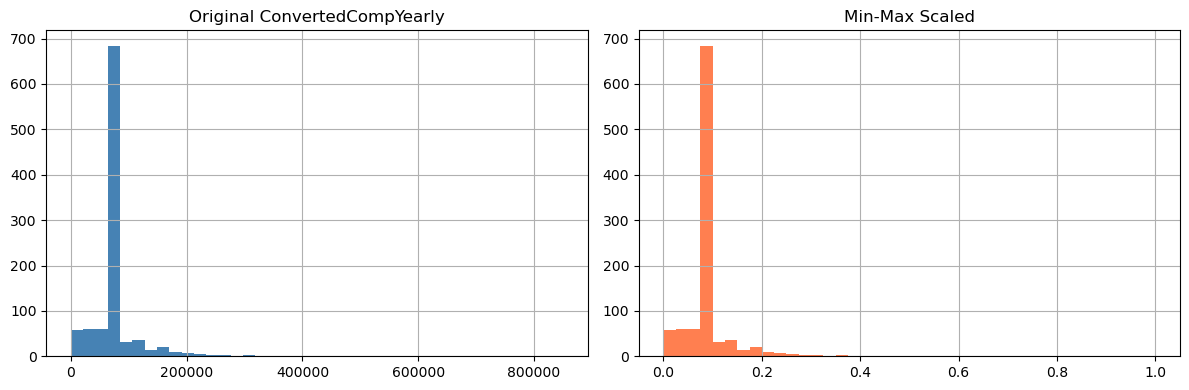

In [11]:
# Min-Max scaling: rescales values to the range [0, 1]
# Formula: (x - min) / (max - min)

comp_min = df['ConvertedCompYearly'].min()
comp_max = df['ConvertedCompYearly'].max()

df['CompYearly_MinMax'] = (df['ConvertedCompYearly'] - comp_min) / (comp_max - comp_min)

print("Min-Max scaled ConvertedCompYearly statistics:")
print(df['CompYearly_MinMax'].describe())

# Quick visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['ConvertedCompYearly'].hist(bins=40, ax=axes[0], color='steelblue')
axes[0].set_title('Original ConvertedCompYearly')
df['CompYearly_MinMax'].hist(bins=40, ax=axes[1], color='coral')
axes[1].set_title('Min-Max Scaled')
plt.tight_layout()
plt.show()

<h5>6.2 Log-transform the ConvertedCompYearly column to reduce skewness.</h5>


Log-transformed ConvertedCompYearly statistics:
count    1000.000000
mean       10.990635
std         0.890790
min         0.693147
25%        11.082835
50%        11.082835
75%        11.082835
max        13.652993
Name: CompYearly_Log, dtype: float64


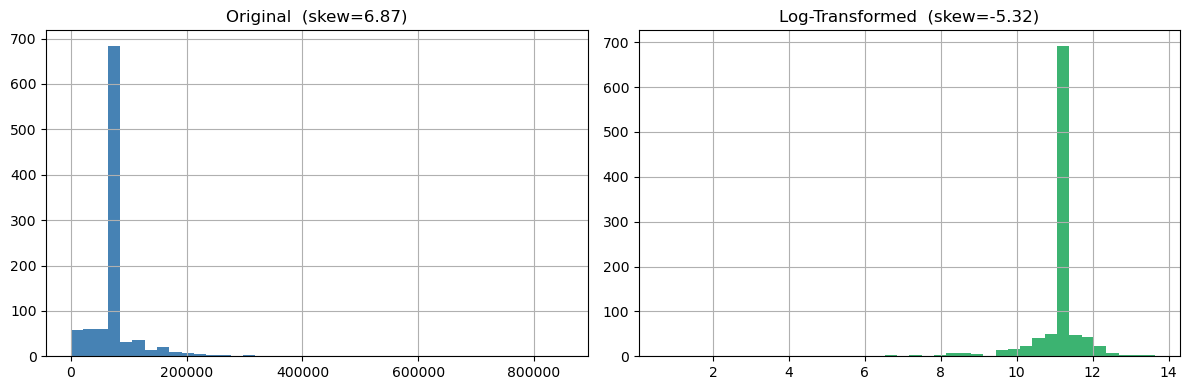

In [12]:
# Log transformation: compress the scale of large values and reduce right skew.
# We use log1p (log(1 + x)) to safely handle any zero values.

df['CompYearly_Log'] = np.log1p(df['ConvertedCompYearly'])

print("Log-transformed ConvertedCompYearly statistics:")
print(df['CompYearly_Log'].describe())

# Visualise skewness before and after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['ConvertedCompYearly'].hist(bins=40, ax=axes[0], color='steelblue')
axes[0].set_title(f"Original  (skew={df['ConvertedCompYearly'].skew():.2f})")
df['CompYearly_Log'].hist(bins=40, ax=axes[1], color='mediumseagreen')
axes[1].set_title(f"Log-Transformed  (skew={df['CompYearly_Log'].skew():.2f})")
plt.tight_layout()
plt.show()

### 7. Feature Engineering


<h5>7.1 Create a new column `ExperienceLevel` based on the `YearsCodePro` column:</h5>


ExperienceLevel distribution:
ExperienceLevel
Senior       243
Expert       213
Unknown      193
Mid-level    186
Junior       165
Name: count, dtype: int64


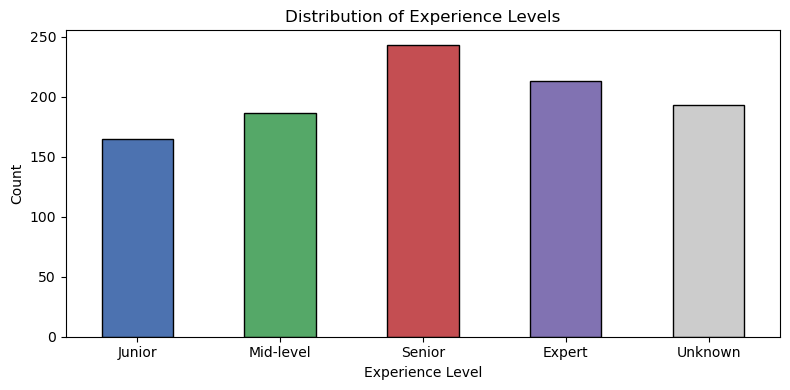

In [13]:
# YearsCodePro contains strings like '5', 'Less than 1 year', 'More than 50 years'.
# Step 1: Convert to numeric

def parse_years(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    if val == 'Less than 1 year':
        return 0.5
    elif val == 'More than 50 years':
        return 51
    else:
        try:
            return float(val)
        except ValueError:
            return np.nan

df['YearsCodePro_Num'] = df['YearsCodePro'].apply(parse_years)

# Step 2: Assign experience level based on years of professional coding
def experience_level(years):
    if pd.isna(years):
        return 'Unknown'
    elif years < 3:
        return 'Junior'        # 0–2 years
    elif years < 7:
        return 'Mid-level'     # 3–6 years
    elif years < 15:
        return 'Senior'        # 7–14 years
    else:
        return 'Expert'        # 15+ years

df['ExperienceLevel'] = df['YearsCodePro_Num'].apply(experience_level)

print("ExperienceLevel distribution:")
print(df['ExperienceLevel'].value_counts())

# Visualise the distribution
order = ['Junior', 'Mid-level', 'Senior', 'Expert', 'Unknown']
counts = df['ExperienceLevel'].value_counts().reindex(order)
counts.plot(kind='bar', color=['#4C72B0','#55A868','#C44E52','#8172B2','#cccccc'],
            edgecolor='black', figsize=(8, 4))
plt.title('Distribution of Experience Levels')
plt.xlabel('Experience Level')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Summary


In this lab, you:

- Explored the dataset to identify inconsistencies and missing values.

- Encoded categorical variables for analysis.

- Handled missing values using imputation techniques.

- Normalized and transformed numerical data to prepare it for analysis.

- Engineered a new feature to enhance data interpretation.


Copyright © IBM Corporation. All rights reserved.
